In [1]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os


In [2]:
load_dotenv()
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [3]:
class jokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: jokeState):

    prompt = f"You are a professional Meme and Joke Creator Comedian. Now Generate a joke on the following topic:\n\Topic: {state['topic']}"
    response = llm.invoke(prompt).content

    return {
        'joke': response
    }

In [5]:
def generate_explanation(state: jokeState):
    prompt = f"You are a Meme and Joke explanation professional. Now Generate a joke explanation on the following joke:\n\Topic: {state['joke']}"
    response = llm.invoke(prompt).content

    return {
        'explanation': response
    }

In [6]:
graph = StateGraph(jokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)


check_pointer = InMemorySaver()

workflow = graph.compile(checkpointer=check_pointer)

In [7]:

config = {
    'configurable':
    {
        'thread_id': '1'
    }
}


workflow.invoke(
    {
        'topic': 'Python is simple'
    },
    config=config
)




{'topic': 'Python is simple',
 'joke': 'Here\'s one:\n\nWhy did Python go to therapy?\n\nBecause it had a lot of "indent"-ational issues and was struggling to "wrap its head" around its own simplicity! But in the end, it just needed to take a "byte"-sized step back and realize, it\'s just a "snake" in the grass, keeping things simple, one line of code at a time! (get it?)',
 'explanation': 'Let\'s break down this joke and explore its various layers of humor.\n\n**The Setup**: The joke starts by introducing Python, which is a programming language, as a character that goes to therapy. This immediately sets a lighthearted and unexpected tone, as programming languages are typically not associated with emotional struggles or personal growth.\n\n**The Punchline**: The joke relies on a series of wordplays to create humor. Here\'s a breakdown of each:\n\n1. **"Indent"-ational issues**: In Python programming, indentation is used to define the structure of the code. The joke plays on this by usi

In [8]:
# For Final State
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'Python is simple', 'joke': 'Here\'s one:\n\nWhy did Python go to therapy?\n\nBecause it had a lot of "indent"-ational issues and was struggling to "wrap its head" around its own simplicity! But in the end, it just needed to take a "byte"-sized step back and realize, it\'s just a "snake" in the grass, keeping things simple, one line of code at a time! (get it?)', 'explanation': 'Let\'s break down this joke and explore its various layers of humor.\n\n**The Setup**: The joke starts by introducing Python, which is a programming language, as a character that goes to therapy. This immediately sets a lighthearted and unexpected tone, as programming languages are typically not associated with emotional struggles or personal growth.\n\n**The Punchline**: The joke relies on a series of wordplays to create humor. Here\'s a breakdown of each:\n\n1. **"Indent"-ational issues**: In Python programming, indentation is used to define the structure of the code. The joke p

In [9]:
# For all states (intermediate and also the final state)
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'Python is simple', 'joke': 'Here\'s one:\n\nWhy did Python go to therapy?\n\nBecause it had a lot of "indent"-ational issues and was struggling to "wrap its head" around its own simplicity! But in the end, it just needed to take a "byte"-sized step back and realize, it\'s just a "snake" in the grass, keeping things simple, one line of code at a time! (get it?)', 'explanation': 'Let\'s break down this joke and explore its various layers of humor.\n\n**The Setup**: The joke starts by introducing Python, which is a programming language, as a character that goes to therapy. This immediately sets a lighthearted and unexpected tone, as programming languages are typically not associated with emotional struggles or personal growth.\n\n**The Punchline**: The joke relies on a series of wordplays to create humor. Here\'s a breakdown of each:\n\n1. **"Indent"-ational issues**: In Python programming, indentation is used to define the structure of the code. The joke 

In [10]:
config2 = {
    'configurable': 
    {
        'thread_id': '2'
    }
}

workflow.invoke(
    {
        'topic': 'What is AI?'
    },
    config=config2
)

{'topic': 'What is AI?',
 'joke': 'Here\'s one:\n\n"AI stands for Artificial Intelligence, but I think it\'s actually \'Awkward Intern\' because every time I ask it to write a joke, it just generates a million dad puns and says \'I\'m still learning, human...\' – I guess that\'s what I get for trying to machine-learn humor!" (ba-dum-tss)',
 'explanation': 'The joke you\'ve provided is a masterful blend of self-aware humor, poking fun at the current state of artificial intelligence (AI), particularly in its ability to understand and generate humor. Let\'s break it down:\n\n1. **Setup and Premise**: The joke starts by establishing a common understanding of AI as "Artificial Intelligence." This is the base knowledge that the listener is expected to have, making the punchline more accessible and amusing.\n\n2. **Subversion of Expectations**: The speaker then subverts this expectation by suggesting an alternative meaning for AI: "Awkward Intern." This unexpected twist creates humor through 

In [11]:
workflow.get_state(config=config2)

StateSnapshot(values={'topic': 'What is AI?', 'joke': 'Here\'s one:\n\n"AI stands for Artificial Intelligence, but I think it\'s actually \'Awkward Intern\' because every time I ask it to write a joke, it just generates a million dad puns and says \'I\'m still learning, human...\' – I guess that\'s what I get for trying to machine-learn humor!" (ba-dum-tss)', 'explanation': 'The joke you\'ve provided is a masterful blend of self-aware humor, poking fun at the current state of artificial intelligence (AI), particularly in its ability to understand and generate humor. Let\'s break it down:\n\n1. **Setup and Premise**: The joke starts by establishing a common understanding of AI as "Artificial Intelligence." This is the base knowledge that the listener is expected to have, making the punchline more accessible and amusing.\n\n2. **Subversion of Expectations**: The speaker then subverts this expectation by suggesting an alternative meaning for AI: "Awkward Intern." This unexpected twist cre

In [12]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'What is AI?', 'joke': 'Here\'s one:\n\n"AI stands for Artificial Intelligence, but I think it\'s actually \'Awkward Intern\' because every time I ask it to write a joke, it just generates a million dad puns and says \'I\'m still learning, human...\' – I guess that\'s what I get for trying to machine-learn humor!" (ba-dum-tss)', 'explanation': 'The joke you\'ve provided is a masterful blend of self-aware humor, poking fun at the current state of artificial intelligence (AI), particularly in its ability to understand and generate humor. Let\'s break it down:\n\n1. **Setup and Premise**: The joke starts by establishing a common understanding of AI as "Artificial Intelligence." This is the base knowledge that the listener is expected to have, making the punchline more accessible and amusing.\n\n2. **Subversion of Expectations**: The speaker then subverts this expectation by suggesting an alternative meaning for AI: "Awkward Intern." This unexpected twist cr

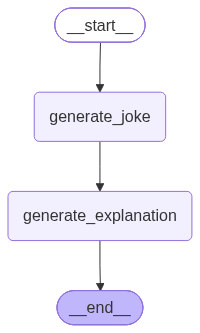

In [13]:

workflow

# Time Travel

In [15]:
workflow.get_state(config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f186a6f-6a0a-68c3-8001-03c6f24d2295'}})

StateSnapshot(values={'topic': 'What is AI?', 'joke': 'Here\'s one:\n\n"AI stands for Artificial Intelligence, but I think it\'s actually \'Awkward Intern\' because every time I ask it to write a joke, it just generates a million dad puns and says \'I\'m still learning, human...\' – I guess that\'s what I get for trying to machine-learn humor!" (ba-dum-tss)'}, next=('generate_explanation',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f186a6f-6a0a-68c3-8001-03c6f24d2295'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-07-23T14:58:28.561325+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f186a6f-615b-6565-8000-028b186c3bfc'}}, tasks=(PregelTask(id='99aba4fb-45f2-40a4-5c0f-aa2d531dd955', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': 'The joke you\'ve provided is a masterful blend of self-aware humor, po

In [16]:
workflow.invoke(
    None,
    config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f186a6f-6a0a-68c3-8001-03c6f24d2295'}}
)

{'topic': 'What is AI?',
 'joke': 'Here\'s one:\n\n"AI stands for Artificial Intelligence, but I think it\'s actually \'Awkward Intern\' because every time I ask it to write a joke, it just generates a million dad puns and says \'I\'m still learning, human...\' – I guess that\'s what I get for trying to machine-learn humor!" (ba-dum-tss)',
 'explanation': 'The joke you\'ve shared is a clever play on the typical expectations of Artificial Intelligence (AI) and the reality of its current limitations, especially when it comes to understanding and generating humor. Let\'s break down the joke to understand its components and why it\'s amusing:\n\n1. **Setup and Misdirection**: The joke starts by setting up a familiar scenario - the explanation of what "AI" stands for, which is commonly known as Artificial Intelligence. This setup primes the listener to expect a straightforward or technical explanation.\n\n2. **Subversion of Expectations**: The punchline subverts these expectations by sugges

In [17]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'What is AI?', 'joke': 'Here\'s one:\n\n"AI stands for Artificial Intelligence, but I think it\'s actually \'Awkward Intern\' because every time I ask it to write a joke, it just generates a million dad puns and says \'I\'m still learning, human...\' – I guess that\'s what I get for trying to machine-learn humor!" (ba-dum-tss)', 'explanation': 'The joke you\'ve shared is a clever play on the typical expectations of Artificial Intelligence (AI) and the reality of its current limitations, especially when it comes to understanding and generating humor. Let\'s break down the joke to understand its components and why it\'s amusing:\n\n1. **Setup and Misdirection**: The joke starts by setting up a familiar scenario - the explanation of what "AI" stands for, which is commonly known as Artificial Intelligence. This setup primes the listener to expect a straightforward or technical explanation.\n\n2. **Subversion of Expectations**: The punchline subverts these ex

# Updating the State

In [ ]:
workflow.update_state(
    {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f185afb-a6ea-6ed3-8000-b738ac648013'}},
    
    {
        'topic': 'Hardware with Software'
    }
)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f185c06-09f7-6bb0-8001-7a3d9ac3ec36'}}

In [26]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'Hardware with Software'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f185c06-09f7-6bb0-8001-7a3d9ac3ec36'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-07-22T11:27:52.647569+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f185afb-a6ea-6ed3-8000-b738ac648013'}}, tasks=(PregelTask(id='758701d6-c831-0383-8ae4-72a05ab3db49', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'What is AI?', 'joke': 'Here\'s one:\n\n"AI stands for Artificial Intelligence, but I think it actually stands for \'Awkward Intern\' because it\'s always trying to learn from humans, but ends up making dad jokes and asking for raises after 5 minutes of training. I mean, who needs a promotions committee when you have a neural netw

In [30]:
workflow.invoke(
    None,
        {'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f185c06-09f7-6bb0-8001-7a3d9ac3ec36'}},

)

{'topic': 'Hardware with Software',
 'joke': 'Why did the hardware and software go to therapy together?\n\nBecause they had a lot of "compatibility issues" and their relationship was always "bugging" them! But in the end, they just needed to "update" their communication and "reboot" their love for each other. Now they\'re "syncing" perfectly and their bond is "unhackable"! (ba-dum-tss)',
 'explanation': 'Let\'s break down this joke and explore the clever wordplay and puns used to create a hilarious and relatable joke about technology.\n\n**The Setup:** The joke starts by introducing the concept of hardware and software going to therapy together. This is already a comedic premise, as it personifies two technical components that aren\'t typically thought of as having personal relationships or emotions.\n\n**The Punchline:** The joke relies on a series of clever puns to create humor. The phrase "compatibility issues" is a common problem in technology, where two or more systems or componen